# Title & Overview

## Vibe Finder 
### IAT 461 Checkpoint 1: EDA
**Data Scientist:** Eri Masahisa (301604643)  **Client:** Kaleb Vinthers (301464332)

**Restatement of the problem**
Vibe Finder wants to build playlists based on how a song sounds, not its labeled
genre. Using only Spotify's audio characteristics (danceability, energy, tempo,
valence, and related features), the task is to discover natural groupings of songs
through clustering, deliberately ignoring the dataset's existing playlist_genre /
playlist_subgenre labels while building the clusters. A good outcome is roughly
5-10 interpretable "vibe" groups, each of which mixes songs from multiple genres
rather than reproducing the existing genre categories.

This is an **unsupervised** problem. There is no target label to predict; the goal
is pattern discovery, not prediction.


# Data Loading & Documentation

**Source:** TidyTuesday / Spotify audio features
(`https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv`),
as specified in the client proposal. Verified to load correctly below.

**Column dictionary (key columns used for this analysis):**

| Column | Description |
|---|---|
| `track_id`, `track_name`, `track_artist` | Track identifiers |
| `playlist_genre`, `playlist_subgenre` | Existing genre labels — **not** used to form clusters, only used afterward to interpret/validate them |
| `danceability` | 0.0–1.0, how suitable the track is for dancing |
| `energy` | 0.0–1.0, perceptual intensity/activity |
| `key` | Estimated musical key (0–11, pitch class) |
| `loudness` | Overall loudness in dB |
| `mode` | 1 = major, 0 = minor |
| `speechiness` | Presence of spoken words |
| `acousticness` | 0.0–1.0 confidence the track is acoustic |
| `instrumentalness` | Predicts whether a track has no vocals |
| `liveness` | Detects presence of a live audience |
| `valence` | 0.0–1.0, musical positiveness |
| `tempo` | Estimated tempo in BPM |
| `duration_ms` | Track duration in milliseconds |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("spotify_songs.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 32833 rows, 23 columns


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

**Known data quality issues** (checked directly against the raw data, not just
assumed from the client's Constraints section):


In [ ]:
# Duplicate check
dup_id = df["track_id"].duplicated().sum()
dup_name_artist = df.duplicated(subset=["track_name", "track_artist"]).sum()
print(f"Duplicated track_id rows: {dup_id} ({dup_id/len(df):.1%})")
print(f"Duplicated (track_name, track_artist) rows: {dup_name_artist} ({dup_name_artist/len(df):.1%})")

# Missing values
print("\nMissing values per column:")
missing = df.isna().sum()
print(missing[missing > 0])

# Loudness anomaly (values should be negative dB, occasionally slightly above 0)
loud_pos = (df["loudness"] > 0).sum()
print(f"\nRows with loudness > 0 dB: {loud_pos}")
print(f"Loudness range: {df['loudness'].min():.2f} to {df['loudness'].max():.2f}")


Duplicated track_id rows: 4477 (13.6%)
Duplicated (track_name, track_artist) rows: 6603 (20.1%)

Missing values per column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Rows with loudness > 0 dB: 6
Loudness range: -46.45 to 1.27


**Findings:**
- **Duplicates confirmed:** About 13.6% of the rows have the same track_id as another
  row (the same song shows up in more than one playlist, like the client's Constraints
  section already mentioned). If we use (track_name, track_artist) instead as the key,
  even more rows count as duplicates (~20%), probably because of re-releases/remasters
  that got a different track_id. **Decision:** I will remove duplicates based on
  track_id before clustering, and just keep the first one, so each song only appears once.
- **Missing values are small** (only 5 rows are missing track_name/track_artist/
  track_album_name) should be fine to just drop these rows instead of filling them in.
- **Loudness anomaly confirmed:** a few rows (6) have loudness values above 0 dB, which
  doesn't really make sense for this feature. Since it's only a small number of rows it
  probably won't affect the clustering much, but I will still check it again before
  modeling (Checkpoint 2).

# Exploratory Data Analysis (EDA)

### Feature Distributions


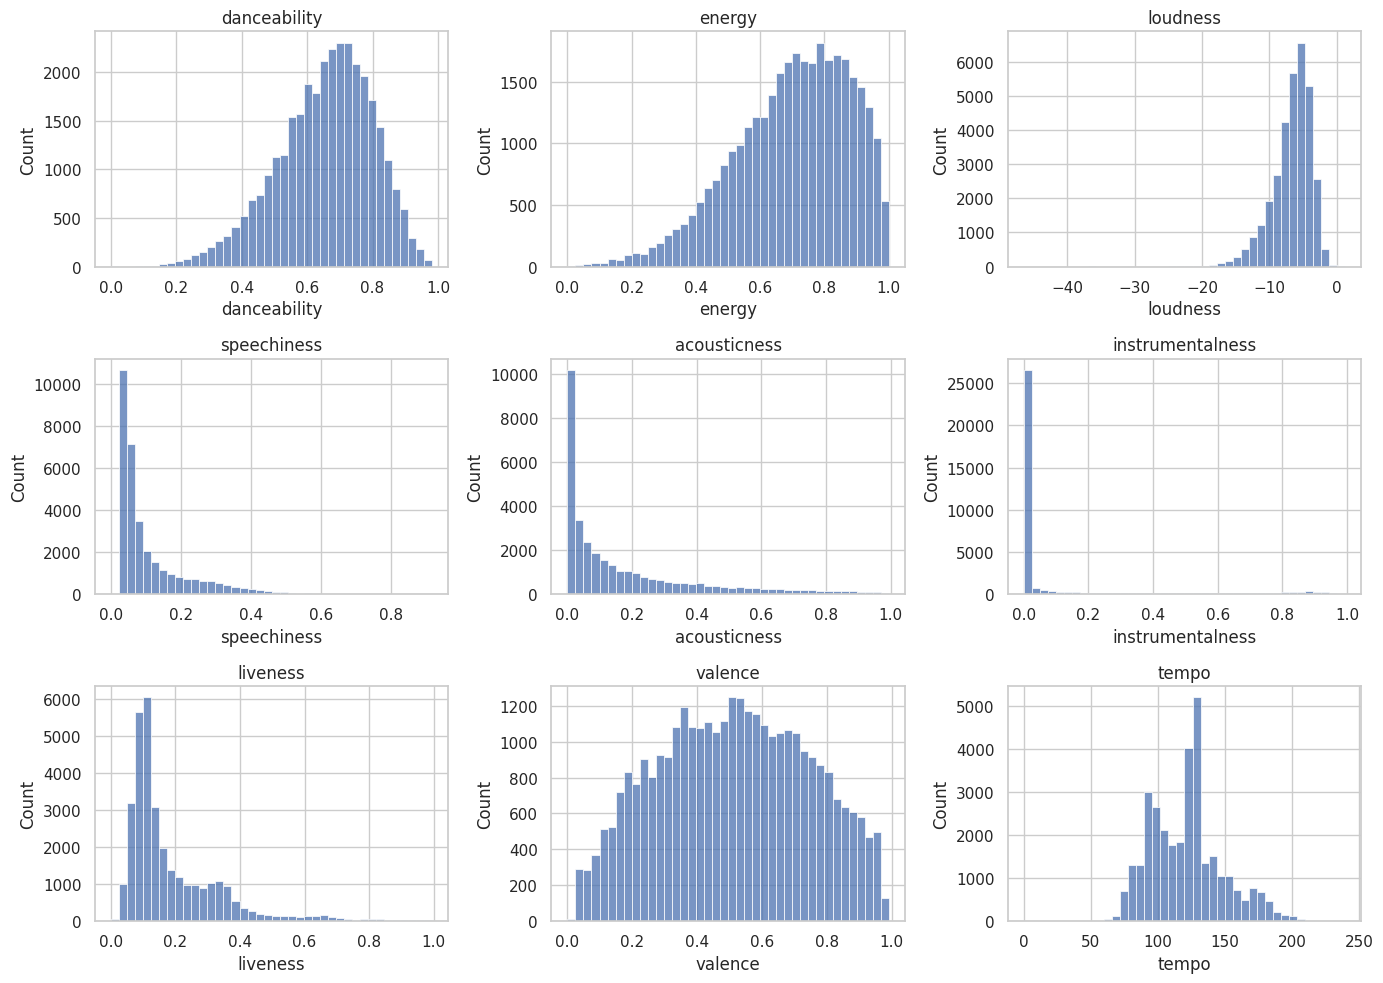

In [ ]:
audio_features = ["danceability", "energy", "loudness", "speechiness",
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, audio_features):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=110)
plt.show()


**Observations:**
- danceability, energy, valence look roughly bell-shaped / a little skewed, and
  they're already between 0-1.These seem like good candidates for clustering without
  much preprocessing needed.
- speechiness, acousticness, instrumentalness, liveness　are pretty
  right-skewed (most tracks are close to 0, with a long tail after that). this
  might be a problem since K-means uses Euclidean distance, which is sensitive to this
  kind of skew. I might try a log-style transform on the most skewed ones when I get
  to modeling.
- loudness and tempo are on a totally different scale compared to the 0-1 features,
  so this confirms that standardization will be needed before clustering, which
  matches what came up in the client Q&A too.


In [ ]:
scale_summary = df[audio_features + ["duration_ms"]].describe().T[["min", "mean", "max", "std"]]
scale_summary


,min,mean,max,std
danceability,0.000000,0.654850,0.983,0.145085
energy,0.000175,0.698619,1.000,0.180910
loudness,-46.448000,-6.719499,1.275,2.988436
speechiness,0.000000,0.107068,0.918,0.101314
acousticness,0.000000,0.175334,0.994,0.219633
instrumentalness,0.000000,0.084747,0.994,0.224230
liveness,0.000000,0.190176,0.996,0.154317
valence,0.000000,0.510561,0.991,0.233146
tempo,0.000000,120.881132,239.440,26.903624
duration_ms,4000.000000,225799.811622,517810.000,59834.006182


### Relationships Between Audio Features

A correlation heatmap to check for strongly related features (relevant for
interpreting clusters later, and for deciding whether any features are redundant).


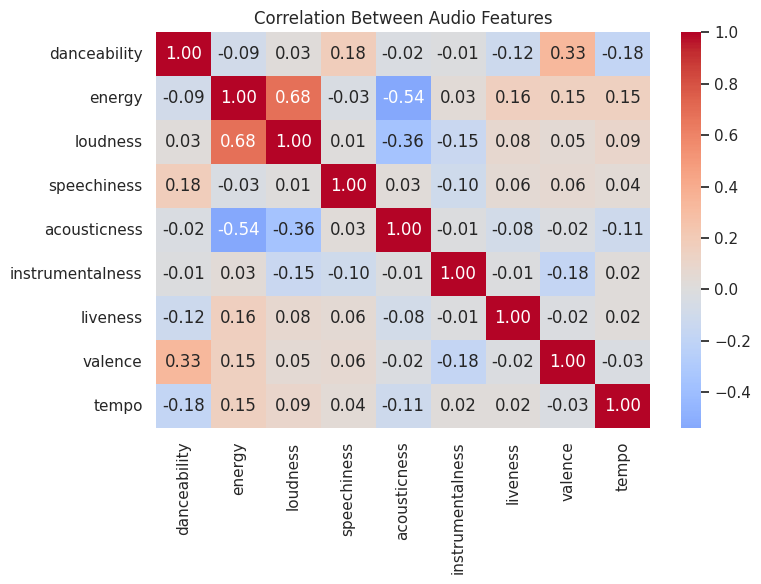

In [ ]:
corr = df[audio_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=110)
plt.show()


**Observations:** energy and loudness show a clear positive correlation, and energy correlates negatively with
acousticness. Both make intuitive sense.
### Existing Genre Labels (for later interpretation only)

Per the problem definition, playlist_genre will not be used to form clusters.
it's shown here only so that, once clusters are built in Checkpoint 2, I can check
whether each cluster mixes genres rather than　reproducing them.


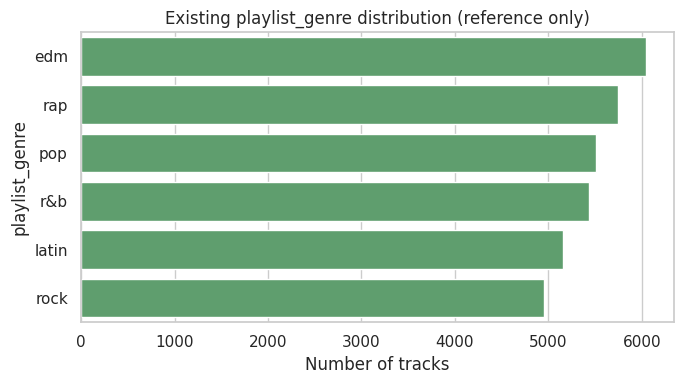

In [ ]:
genre_counts = df["playlist_genre"].value_counts()
plt.figure(figsize=(7, 4))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#55A868")
plt.xlabel("Number of tracks")
plt.title("Existing playlist_genre distribution (reference only)")
plt.tight_layout()
plt.savefig("fig_genre_counts.png", dpi=110)
plt.show()


Genres are reasonably balanced (4,951–6,043 tracks each across 6 genres), so no
single genre dominates the dataset going into clustering.


# Problems Sections


**Not part of Checkpoint 1.** 

This section will be completed with full modeling and evaluation at Checkpoint 2.


# Assumptions Log

| Ambiguity in proposal | Resolution |
|---|---|
| "danceability, energy, tempo, valence, etc." — full feature list not specified | Client confirmed (Discord) additional features may be added at my discretion. Planning to use all 9 audio-character columns (`danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`), excluding non-audio metadata (`duration_ms`, `track_popularity`). Will revisit if EDA suggests otherwise. |
| Exact number of clusters not specified (proposal said "5-10 groups") | Client confirmed this is flexible. Will use the elbow method / silhouette score within the 5-10 range at modeling time (Checkpoint 2). |
| Duplicate handling not fully specified | Client's Constraints section flagged duplicates as a known issue; decided to dedupe on `track_id`, keeping first occurrence. |


# Limitations

**Not part of Checkpoint 1.**  will be completed after modeling

# Executive Summary

**Not part of Checkpoint 1.** 

# Links
